In [1]:
from src.get_data import get_data

df = get_data()

/run/media/jc-bazziteDsk/Shared/SharedDev/Experimentos_TempName/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cache directory: /run/media/jc-bazziteDsk/Shared/SharedDev/Experimentos_TempName/AC3-EDA/data/raw
Path to file: /run/media/jc-bazziteDsk/Shared/SharedDev/Experimentos_TempName/AC3-EDA/data/raw/datasets/debayank2024/house-price-prediction/versions/1/modified_data.csv
First 5 records:
          date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0  2014-05-02   313000.0       3.0       1.50         1340      7912     1.5   
1  2014-05-02  2384000.0       5.0       2.50         3650      9050     2.0   
2  2014-05-02   342000.0       3.0       2.00         1930     11947     1.0   
3  2014-05-02   420000.0       3.0       2.25         2000      8030     1.0   
4  2014-05-02   550000.0       4.0       2.50         1940     10500     1.0   

   waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0           0     0          3        1340              0      1955   
1           0     4          5        3370            280      1921   
2           0     0  

## This is a level 2 title

some texto

---

more texto

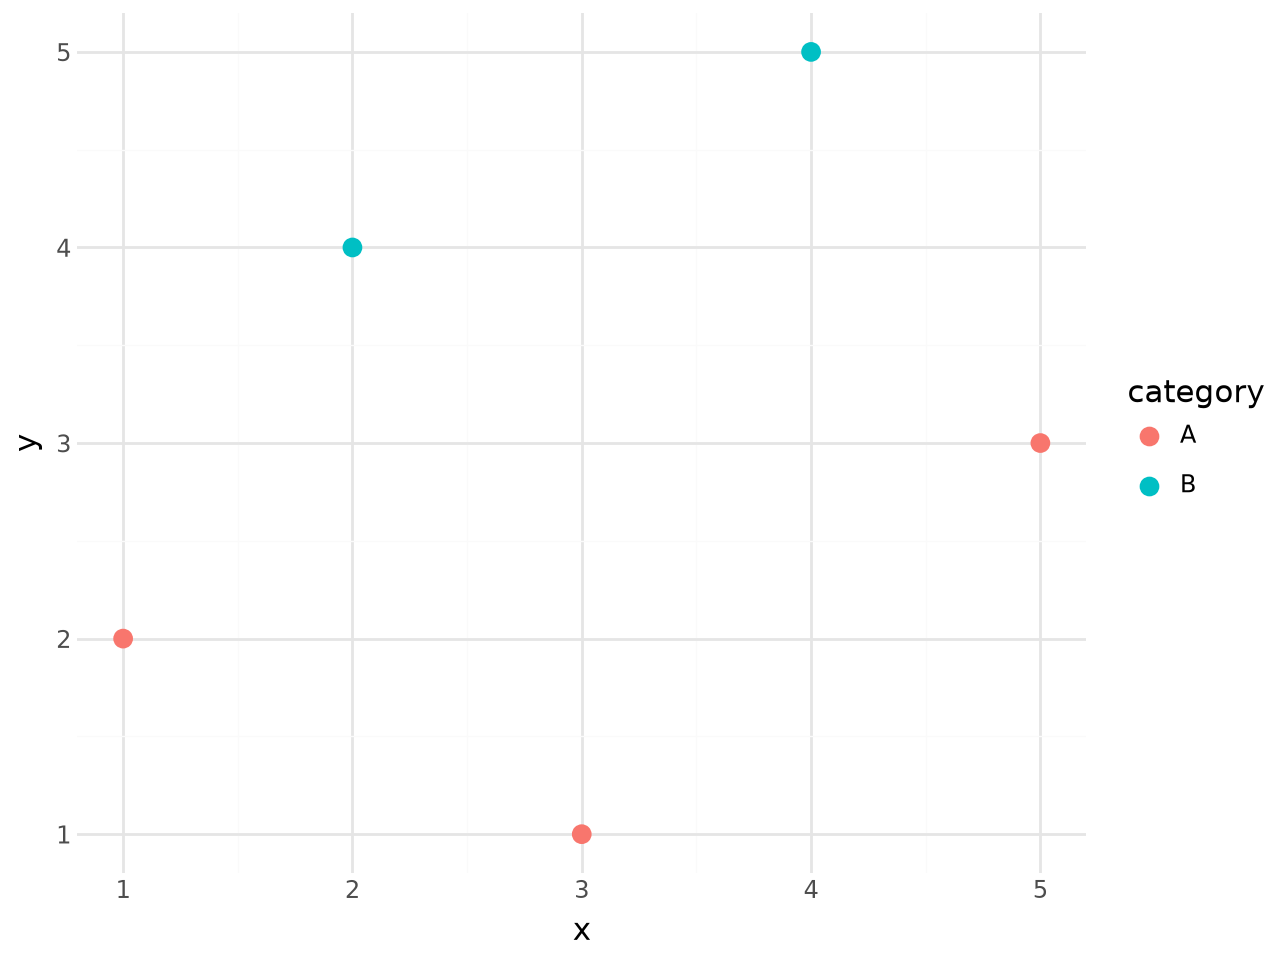

              x         y
count  5.000000  5.000000
mean   3.000000  3.000000
std    1.581139  1.581139
min    1.000000  1.000000
25%    2.000000  2.000000
50%    3.000000  3.000000
75%    4.000000  4.000000
max    5.000000  5.000000
Probability of a value falling below 1.56: 0.940620059405207
Data looks normally distributed (Fail to reject H0)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                 -0.213
Method:                 Least Squares   F-statistic:                    0.2967
Date:                Thu, 03 Sep 2026   Prob (F-statistic):              0.624
Time:                        12:54:54   Log-Likelihood:                -8.5918
No. Observations:                   5   AIC:                             21.18
Df Residuals:                       3   BIC:                             20.40
Df Model:            

/run/media/jc-bazziteDsk/Shared/SharedDev/Experimentos_TempName/.venv/lib64/python3.14/site-packages/statsmodels/regression/linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.


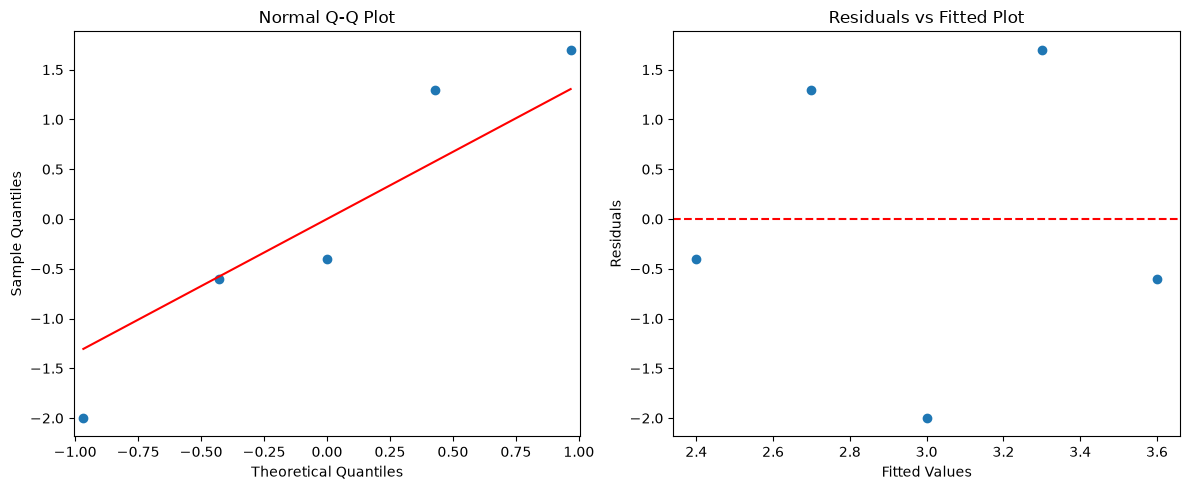

In [14]:
import pandas as pd
from plotnine import ggplot, aes, geom_point, theme_minimal

# 1. Create a standard pandas DataFrame
df = pd.DataFrame({
    'x': [1, 2, 3, 4, 5],
    'y': [2, 4, 1, 5, 3],
    'category': ['A', 'B', 'A', 'B', 'A']
})

# 2. Pass it directly into ggplot, just like in R!
chart = (
    ggplot(df, aes(x='x', y='y', color='category')) 
    + geom_point(size=3)
    + theme_minimal()
)

chart.show()

print(df.describe())

##
from scipy import stats

# Generate a normal distribution (mean=0, std=1)
norm_dist = stats.norm(loc=0, scale=1)

# Calculate the probability of a value falling below 1.56 (Cumulative Distribution Function)
cdf_value = norm_dist.cdf(1.56)

print(f"Probability of a value falling below 1.56: {cdf_value}")

##
# Shapiro-Wilk Test for Normality
stat, p_value = stats.shapiro(df['y'])

if p_value > 0.05:
    print("Data looks normally distributed (Fail to reject H0)")
else:
    print("Data is not normally distributed (Reject H0)")

##
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Fit an Ordinary Least Squares (OLS) Linear Regression model
# 'y' is the target, 'x' is the predictor
model = smf.ols('y ~ x', data=df).fit()

# View the full statistical breakdown of the model
print(model.summary())

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Extract residuals and predicted values
residuals = model.resid
fitted_values = model.fittedvalues

# 2. Check for Normality (Shapiro-Wilk Test)
# H0: Residuals are normally distributed
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk p-value: {shapiro_test.pvalue:.4f}")

# 3. Check for Constant Variance / Homoscedasticity (Breusch-Pagan Test)
# H0: Homoscedasticity is present
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, model.model.exog)
print(f"Breusch-Pagan p-value: {bp_test[1]:.4f}")


# Create a 1x2 subplot canvas
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: QQ-Plot (Points should lie tightly on the red line)
sm.qqplot(residuals, line='s', ax=ax[0])
ax[0].set_title('Normal Q-Q Plot')

# Right plot: Residuals vs Fitted (Should look like a random cloud, no patterns/shapes)
ax[1].scatter(fitted_values, residuals)
ax[1].axhline(y=0, color='red', linestyle='--')
ax[1].set_xlabel('Fitted Values')
ax[1].set_ylabel('Residuals')
ax[1].set_title('Residuals vs Fitted Plot')

plt.tight_layout()
plt.show()


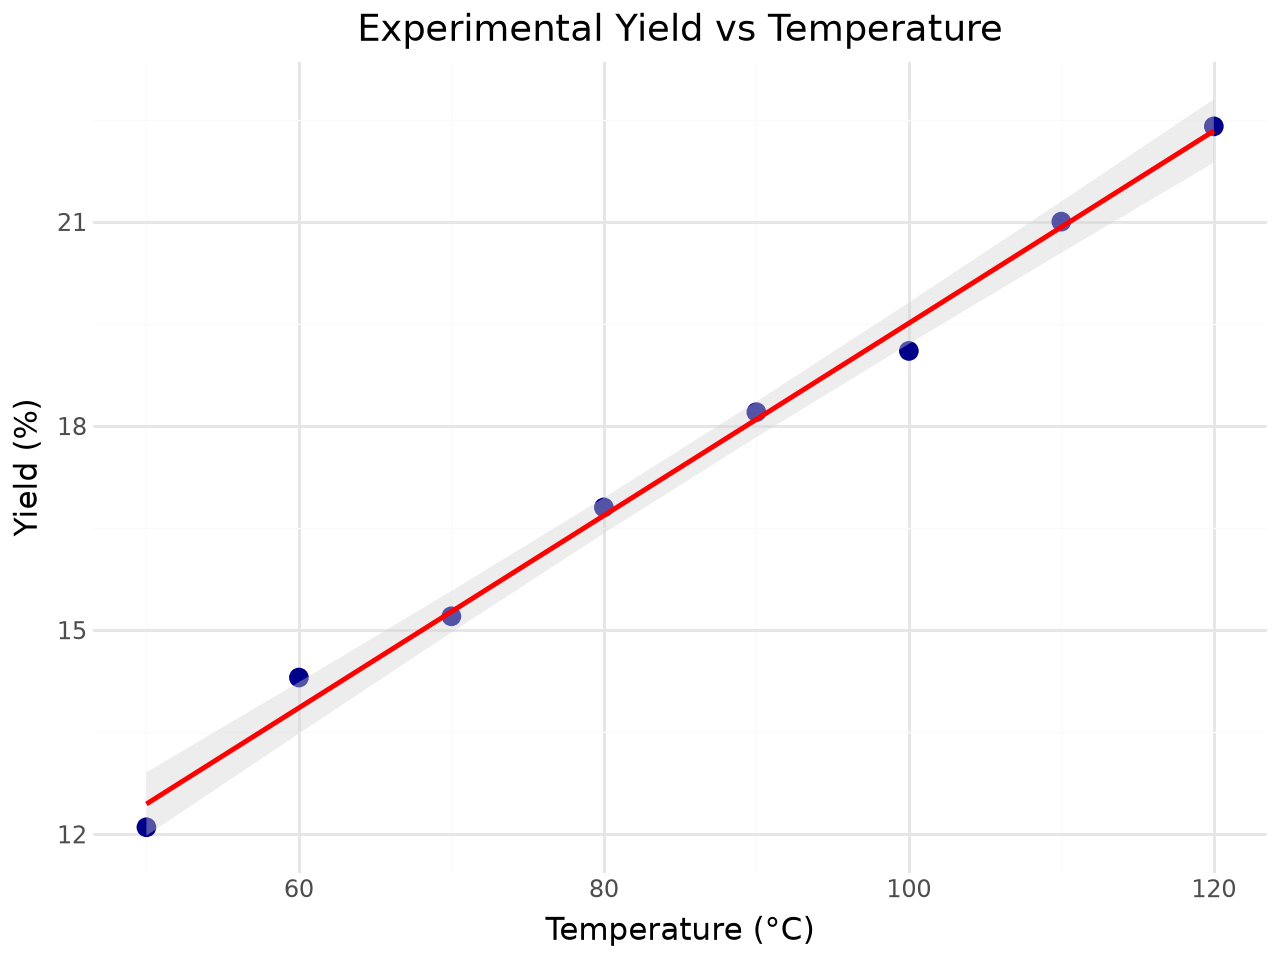

In [17]:
import pandas as pd
from plotnine import ggplot, aes, geom_point, geom_smooth, labs, theme_minimal

# Experimental data
data = pd.DataFrame({
    'Temperature': [50, 60, 70, 80, 90, 100, 110, 120],
    'Yield': [12.1, 14.3, 15.2, 16.8, 18.2, 19.1, 21.0, 22.4]
})

# Plot Data Points + Regression Line with Confidence Intervlas
regression_plot = (
    ggplot(data, aes(x='Temperature', y='Yield'))
    + geom_point(size=3, color='darkblue')
    + geom_smooth(method='lm', color='red', fill='lightgray', level=0.95)
    + labs(title='Experimental Yield vs Temperature', x='Temperature (°C)', y='Yield (%)')
    + theme_minimal()
)

regression_plot.show()


In [18]:
import statsmodels.formula.api as smf

# Fit the OLS model
model = smf.ols('Yield ~ Temperature', data=data).fit()

# Create a dedicated diagnostic dataframe
diagnostics = pd.DataFrame({
    'Fitted': model.fittedvalues,
    'Residuals': model.resid
}).sort_values('Residuals') # Sorting simplifies the Q-Q math

# Add theoretical quantiles for the Q-Q plot manual calculation
import scipy.stats as stats
import numpy as np

n = len(diagnostics)
# Calculate standard normal theoretical quantiles for a sample size of n
diagnostics['Theoretical_Quantiles'] = stats.norm.ppf((np.arange(1, n + 1) - 0.5) / n)
# Standardize the residuals so they map 1:1 on a 45-degree line
diagnostics['Standardized_Residuals'] = (diagnostics['Residuals'] - diagnostics['Residuals'].mean()) / diagnostics['Residuals'].std()


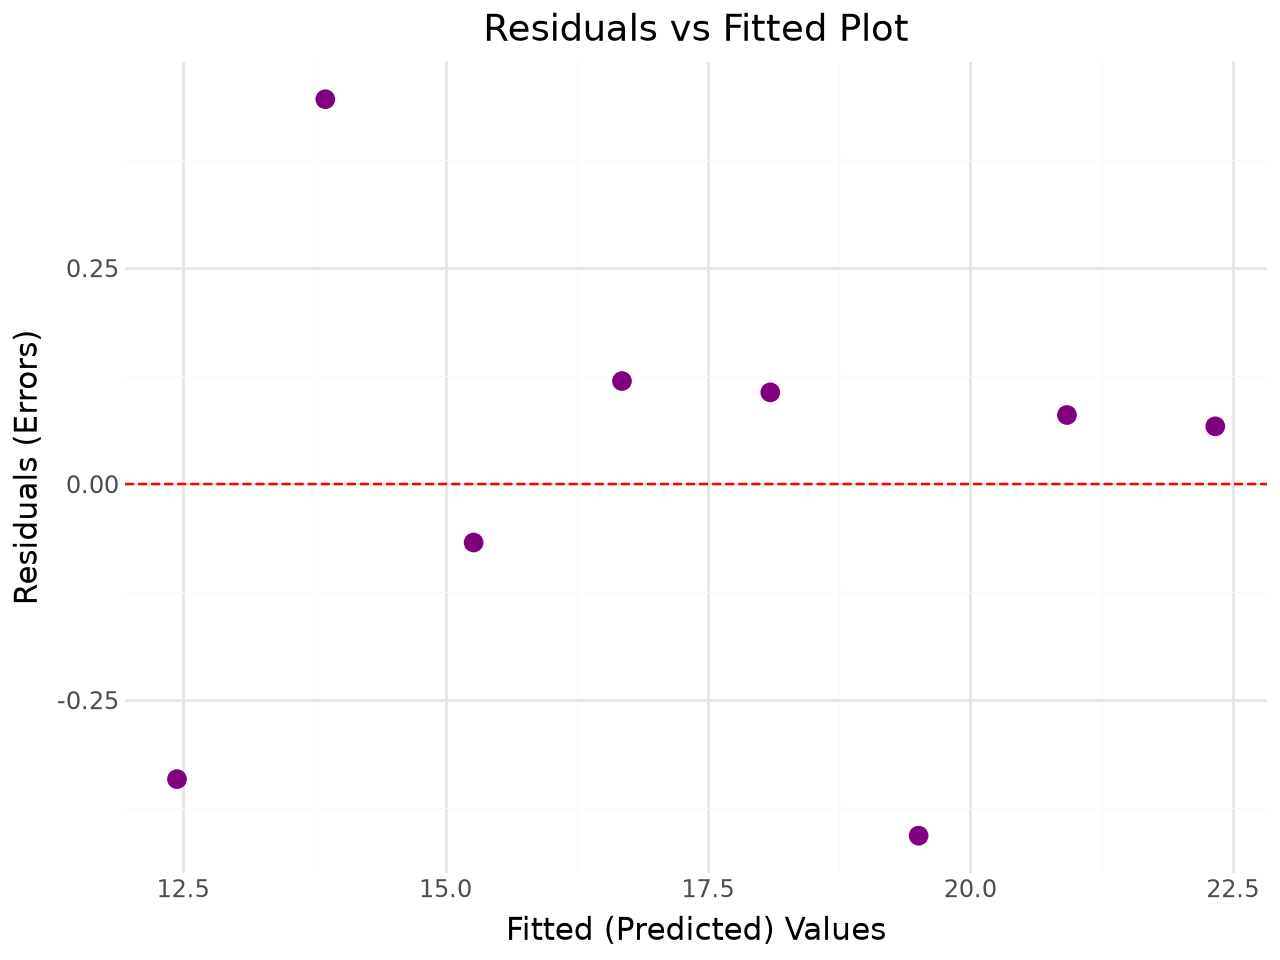

In [20]:
from plotnine import geom_hline

res_vs_fit = (
    ggplot(diagnostics, aes(x='Fitted', y='Residuals'))
    + geom_point(size=3, color='purple')
    + geom_hline(yintercept=0, color='red', linetype='dashed')
    + labs(
        title='Residuals vs Fitted Plot',
        x='Fitted (Predicted) Values',
        y='Residuals (Errors)'
    )
    + theme_minimal()
)

res_vs_fit.show()


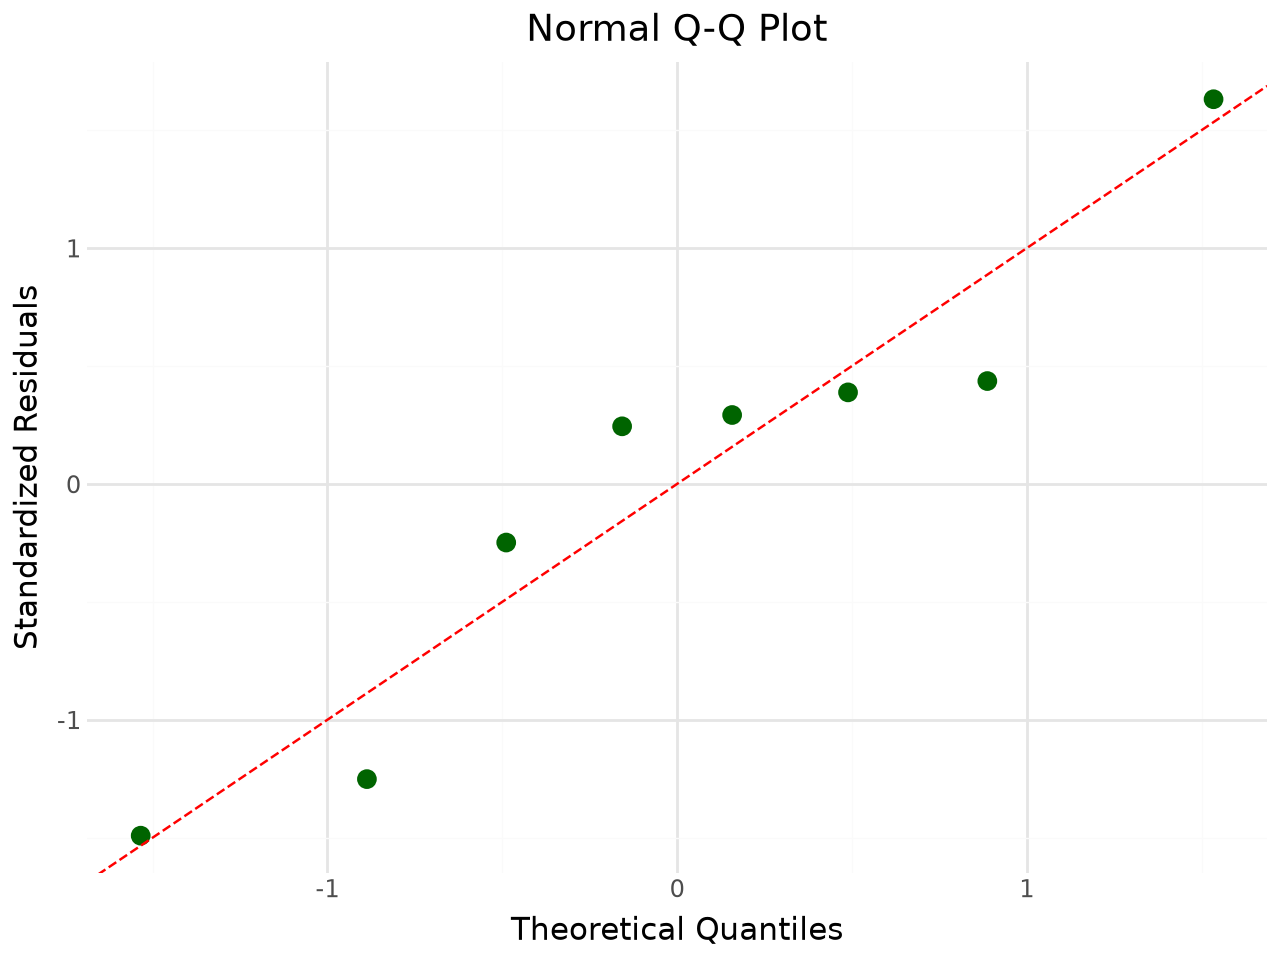

In [22]:
from plotnine import geom_abline

qq_plot = (
    ggplot(diagnostics, aes(x='Theoretical_Quantiles', y='Standardized_Residuals'))
    + geom_point(size=3, color='darkgreen')
    + geom_abline(slope=1, intercept=0, color='red', linetype='dashed')
    + labs(
        title='Normal Q-Q Plot',
        x='Theoretical Quantiles',
        y='Standardized Residuals'
    )
    + theme_minimal()
)

qq_plot.show()
